<a href="https://colab.research.google.com/github/Tauhid-Topu-007/Depression-dataset/blob/main/Depression%20final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr
import warnings
warnings.filterwarnings('ignore')

In [7]:
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score, matthews_corrcoef,
                             balanced_accuracy_score)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.utils.class_weight import compute_class_weight

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

In [9]:
from imblearn.over_sampling import SMOTE

In [10]:
data = pd.read_csv('depression_data.csv')

In [11]:
data.shape

(18345, 16)

In [12]:
data.head()

,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [13]:
data.isnull().sum()

,0
Name,0
Age,0
Marital Status,0
Education Level,0
Number of Children,0
Smoking Status,0
Physical Activity Level,1
Employment Status,1
Income,1
Alcohol Consumption,1


In [14]:
# Option A: If you have a real 'Depression_Diagnosis' column
if 'Depression_Diagnosis' in data.columns:
    y = data['Depression_Diagnosis'].map({'Yes': 1, 'No': 0})
    print("\nUsing existing Depression_Diagnosis as target")

else:
    # Use a combination of features that represent a clinical outcome
    # This is for demonstration - in practice, you'd have a real target
    clinical_factors = ['History of Mental Illness', 'Family History of Depression']

In [15]:
y = ((data['History of Mental Illness'] == 'Yes') &
         (data['Family History of Depression'] == 'Yes')).astype(int)

print("\nCreated synthetic target based on clinical history combination")
print("NOTE: This is for demonstration. In practice, use real diagnostic data")


Created synthetic target based on clinical history combination
NOTE: This is for demonstration. In practice, use real diagnostic data


In [16]:
columns_to_exclude = ['Name', 'Depression_Diagnosis'] if 'Depression_Diagnosis' in data.columns else ['Name']
if 'History of Mental Illness' in data.columns:
    # If using synthetic target, exclude the features used to create it
    columns_to_exclude.extend(['History of Mental Illness', 'Family History of Depression'])

In [17]:
feature_candidates = [
    'Age', 'Marital Status', 'Education Level', 'Number of Children',
    'Smoking Status', 'Physical Activity Level', 'Employment Status',
    'Income', 'Alcohol Consumption', 'Dietary Habits', 'Sleep Patterns',
    'History of Substance Abuse', 'Chronic Medical Conditions'
]


In [18]:
# Use only available features
available_features = [f for f in feature_candidates if f in data.columns]
X = data[available_features].copy()

In [19]:
print(f"\nFeatures used for prediction (no leakage): {len(available_features)}")
print(f"Features: {available_features}")


Features used for prediction (no leakage): 13
Features: ['Age', 'Marital Status', 'Education Level', 'Number of Children', 'Smoking Status', 'Physical Activity Level', 'Employment Status', 'Income', 'Alcohol Consumption', 'Dietary Habits', 'Sleep Patterns', 'History of Substance Abuse', 'Chronic Medical Conditions']


In [20]:
# Label encoding for ordinal features
ordinal_mappings = {
    'Education Level': {'High School': 0, 'Associate Degree': 1, "Bachelor's Degree": 2,
                        "Master's Degree": 3, 'PhD': 4},
    'Physical Activity Level': {'Sedentary': 0, 'Moderate': 1, 'Active': 2},
    'Alcohol Consumption': {'Low': 0, 'Moderate': 1, 'High': 2},
    'Dietary Habits': {'Unhealthy': 0, 'Moderate': 1, 'Healthy': 2},
    'Sleep Patterns': {'Poor': 0, 'Fair': 1, 'Good': 2},
    'Smoking Status': {'Non-smoker': 0, 'Former': 1, 'Current': 2}
}


In [21]:
for col, mapping in ordinal_mappings.items():
    if col in X.columns:
        X[col] = X[col].map(mapping)


In [22]:
# One-hot encoding for nominal features
nominal_features = ['Marital Status', 'Employment Status']
for col in nominal_features:
    if col in X.columns:
        dummies = pd.get_dummies(X[col], prefix=col, drop_first=True)
        X = pd.concat([X.drop(columns=[col]), dummies], axis=1)

In [23]:
# handle outliers
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR  # More conservative
    upper_bound = Q3 + 3 * IQR
    df[column] = df[column].clip(lower_bound, upper_bound)

In [24]:
for col in ['Age', 'Income', 'Number of Children']:
    if col in X.columns:
        cap_outliers(X, col)
        print(f"Capped outliers for {col}")

Capped outliers for Age
Capped outliers for Income
Capped outliers for Number of Children


In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

In [26]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(X)

selected_features = X.columns[selector.get_support()].tolist()
X = X[selected_features]

In [27]:
print(f"\nFeatures after variance threshold: {len(selected_features)}")


Features after variance threshold: 15


In [28]:
# Calculate feature significance
feature_stats = []
for col in X.columns:
    if X[col].dtype in ['int64', 'float64']:
        corr, p_value = pointbiserialr(y, X[col])
        feature_stats.append({'Feature': col, 'Correlation': abs(corr), 'P-Value': p_value})
    else:
        contingency = pd.crosstab(y, X[col])
        chi2, p_value, dof, expected = chi2_contingency(contingency)
        feature_stats.append({'Feature': col, 'Correlation': chi2, 'P-Value': p_value})

In [29]:
feature_stats_df = pd.DataFrame(feature_stats).sort_values('P-Value')

In [30]:
# top 10 significant features
print(feature_stats_df.head(10).to_string())

                         Feature  Correlation       P-Value
13        Marital Status_Widowed   322.449140  4.240644e-72
0                            Age     0.073037  3.960422e-23
14  Employment Status_Unemployed    90.242966  2.106379e-21
11        Marital Status_Married    57.688797  3.070467e-14
12         Marital Status_Single    30.957114  2.637934e-08
2             Number of Children     0.037171  4.753190e-07
9     History of Substance Abuse     0.013554  6.638358e-02
10    Chronic Medical Conditions     0.013281  7.205113e-02
1                Education Level     0.007431  3.141859e-01
3                 Smoking Status          NaN           NaN


In [31]:
# Keep only significant features (p < 0.05)
significant_features = feature_stats_df[feature_stats_df['P-Value'] < 0.05]['Feature'].tolist()
X = X[significant_features]
print(f"\nFinal features after significance testing: {len(significant_features)}")



Final features after significance testing: 6


In [32]:
print(y.value_counts())

0    16843
1     1502
Name: count, dtype: int64


In [33]:
print(f"Imbalance ratio: {y.value_counts().iloc[0] / y.value_counts().iloc[1]:.2f}")

Imbalance ratio: 11.21


In [34]:
# Compute class weights for models
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict = dict(zip(np.unique(y), class_weights))

In [35]:
# Apply SMOTE for oversampling
smote = SMOTE(random_state=42, sampling_strategy='auto')
X_resampled, y_resampled = smote.fit_resample(X, y)


In [36]:
## aftert smote
print(pd.Series(y_resampled).value_counts())

1    16843
0    16843
Name: count, dtype: int64


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

In [38]:
X_train.shape

(26948, 6)

In [39]:
X_test.shape

(6738, 6)

In [40]:
#feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

In [42]:
#models definitions with regularization
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000, class_weight='balanced',
        C=0.1, penalty='l2'  # Strong regularization
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42, class_weight='balanced',
        max_depth=5, min_samples_split=20, min_samples_leaf=10  # Pruned
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42, n_estimators=100, class_weight='balanced',
        max_depth=10, min_samples_split=20, min_samples_leaf=10,
        n_jobs=-1
    ),
    'Gradient Boost': GradientBoostingClassifier(
        random_state=42, n_estimators=100, learning_rate=0.05,
        max_depth=3, min_samples_split=20, min_samples_leaf=10,
        subsample=0.8
    ),
    'XGBoost': XGBClassifier(
        random_state=42, eval_metric='logloss',
        scale_pos_weight=class_weight_dict[1]/class_weight_dict[0],
        max_depth=3, learning_rate=0.05, n_estimators=100,
        reg_alpha=0.1, reg_lambda=1.0  # L1/L2 regularization
    ),
    'MLP Classifier': MLPClassifier(
        random_state=42, max_iter=500, early_stopping=True,
        validation_fraction=0.1, hidden_layer_sizes=(50, 25),
        alpha=0.01, learning_rate_init=0.001  # Dropout/regularization
    )
}

In [43]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Comprehensive model evaluation with cross-validation"""

    model.fit(X_train, y_train)

    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Probabilities for AUC
    if hasattr(model, "predict_proba"):
        y_pred_proba_test = model.predict_proba(X_test)[:, 1]
        y_pred_proba_train = model.predict_proba(X_train)[:, 1]
        auc_test = roc_auc_score(y_test, y_pred_proba_test)
        auc_train = roc_auc_score(y_train, y_pred_proba_train)
    else:
        auc_train = auc_test = None

    # Metrics
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    balanced_acc = balanced_accuracy_score(y_test, y_pred_test)
    mcc = matthews_corrcoef(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='balanced_accuracy')

    # Check for overfitting
    overfitting_gap = train_acc - test_acc

    print(f"\n{'='*60}")
    print(f"{model_name} Results")
    print(f"{'='*60}")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Overfitting Gap: {overfitting_gap:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print(f"CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    if auc_test:
        print(f"Test AUC: {auc_test:.4f}")

    # Warning for potential overfitting
    if overfitting_gap > 0.1:
        print(f"⚠️ WARNING: Possible overfitting! Train-test gap = {overfitting_gap:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred_test, target_names=['Low Risk', 'High Risk']))

    return {
        'Model': model_name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Overfitting Gap': overfitting_gap,
        'Balanced Acc': balanced_acc,
        'F1': f1,
        'MCC': mcc,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test AUC': auc_test if auc_test else None,
        'Model Object': model
    }


In [44]:
# train and evaluate all models
results = []
for name, model in models.items():
    try:
        result = evaluate_model(model, X_train_scaled, X_test_scaled,
                                y_train, y_test, name)
        results.append(result)
    except Exception as e:
        print(f"Error with {name}: {str(e)}")



Logistic Regression Results
Training Accuracy: 0.5843
Test Accuracy: 0.5892
Overfitting Gap: -0.0049
Balanced Accuracy: 0.5892
F1-Score: 0.4910
MCC: 0.1934
CV Accuracy: 0.5853 (+/- 0.0140)
Test AUC: 0.6112

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.56      0.78      0.66      3369
   High Risk       0.65      0.40      0.49      3369

    accuracy                           0.59      6738
   macro avg       0.60      0.59      0.57      6738
weighted avg       0.60      0.59      0.57      6738


Decision Tree Results
Training Accuracy: 0.6005
Test Accuracy: 0.5936
Overfitting Gap: 0.0068
Balanced Accuracy: 0.5936
F1-Score: 0.5159
MCC: 0.1978
CV Accuracy: 0.5944 (+/- 0.0097)
Test AUC: 0.6275

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.57      0.75      0.65      3369
   High Risk       0.64      0.43      0.52      3369

    accuracy                           0.59      6738


In [45]:
comparison_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'Model Object'}
                               for r in results])

In [46]:
print(comparison_df.to_string(index=False))

              Model  Train Acc  Test Acc  Overfitting Gap  Balanced Acc       F1      MCC  CV Mean   CV Std  Test AUC
Logistic Regression   0.584311  0.589196        -0.004885      0.589196 0.490989 0.193367 0.585349 0.007005  0.611228
      Decision Tree   0.600490  0.593648         0.006842      0.593648 0.515912 0.197773 0.594402 0.004849  0.627456
      Random Forest   0.682759  0.669783         0.012976      0.669783 0.663542 0.339801 0.661162 0.005784  0.740222
     Gradient Boost   0.609693  0.604779         0.004914      0.604779 0.553263 0.215364 0.604682 0.004983  0.648651
            XGBoost   0.500000  0.500000         0.000000      0.500000 0.666667 0.000000 0.500000 0.000000  0.645177
     MLP Classifier   0.604015  0.601069         0.002947      0.601069 0.550802 0.207398 0.588278 0.007922  0.640582


In [47]:
best_model_result = min(results, key=lambda x: x['Overfitting Gap'])
best_model = best_model_result['Model Object']
best_model_name = best_model_result['Model']

In [48]:
print(f"\nBEST MODEL: {best_model_name}")
print(f"   Test Accuracy: {best_model_result['Test Acc']:.4f}")
print(f"   Balanced Accuracy: {best_model_result['Balanced Acc']:.4f}")
print(f"   Overfitting Gap: {best_model_result['Overfitting Gap']:.4f}")


BEST MODEL: Logistic Regression
   Test Accuracy: 0.5892
   Balanced Accuracy: 0.5892
   Overfitting Gap: -0.0049


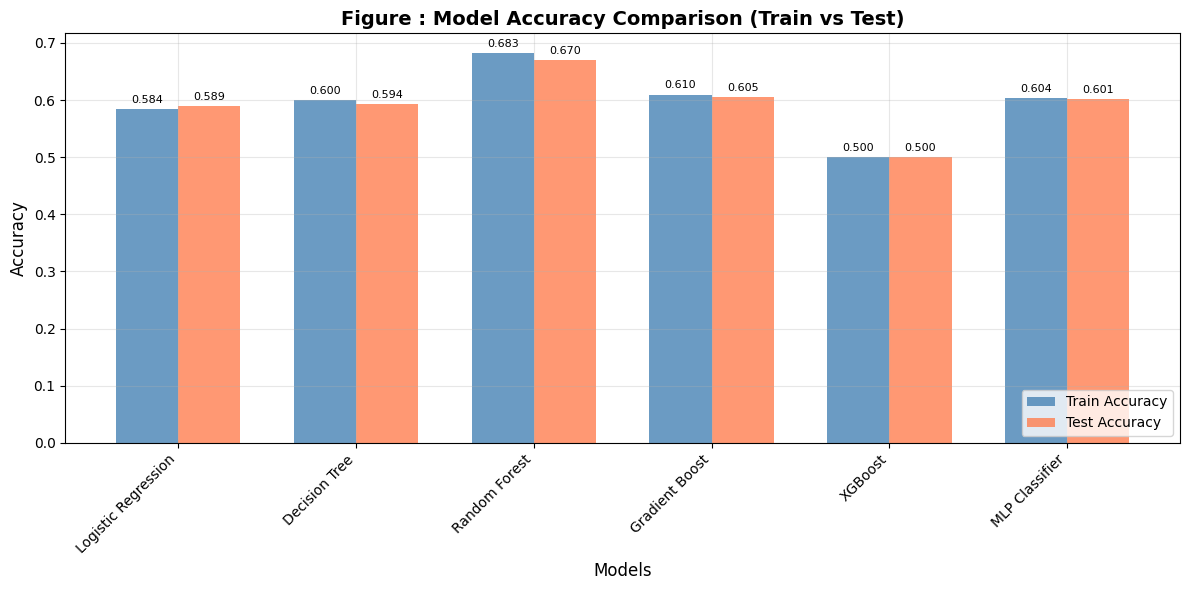

In [112]:
plt.figure(figsize=(12, 6))
x = np.arange(len(comparison_df['Model']))
width = 0.35

bars1 = plt.bar(x - width/2, comparison_df['Train Acc'], width,
                label='Train Accuracy', alpha=0.8, color='steelblue')
bars2 = plt.bar(x + width/2, comparison_df['Test Acc'], width,
                label='Test Accuracy', alpha=0.8, color='coral')

plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Figure : Model Accuracy Comparison (Train vs Test)', fontsize=14, fontweight='bold')
plt.xticks(x, comparison_df['Model'], rotation=45, ha='right')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('figure1_model_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

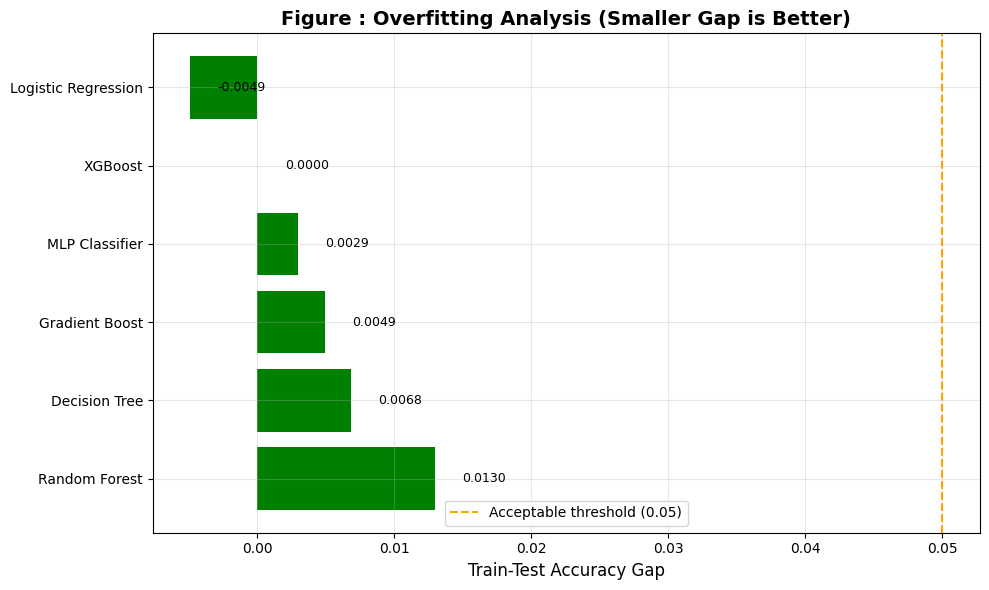

In [114]:
plt.figure(figsize=(10, 6))
overfitting_df = comparison_df.sort_values('Overfitting Gap', ascending=False)
colors = ['red' if gap > 0.05 else 'green' for gap in overfitting_df['Overfitting Gap']]
bars = plt.barh(overfitting_df['Model'], overfitting_df['Overfitting Gap'], color=colors)
plt.xlabel('Train-Test Accuracy Gap', fontsize=12)
plt.title('Figure : Overfitting Analysis (Smaller Gap is Better)', fontsize=14, fontweight='bold')
plt.axvline(x=0.05, color='orange', linestyle='--', label='Acceptable threshold (0.05)')
plt.legend()
plt.grid(True, alpha=0.3)

for bar, gap in zip(bars, overfitting_df['Overfitting Gap']):
    plt.text(gap + 0.002, bar.get_y() + bar.get_height()/2,
             f'{gap:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('figure2_overfitting_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

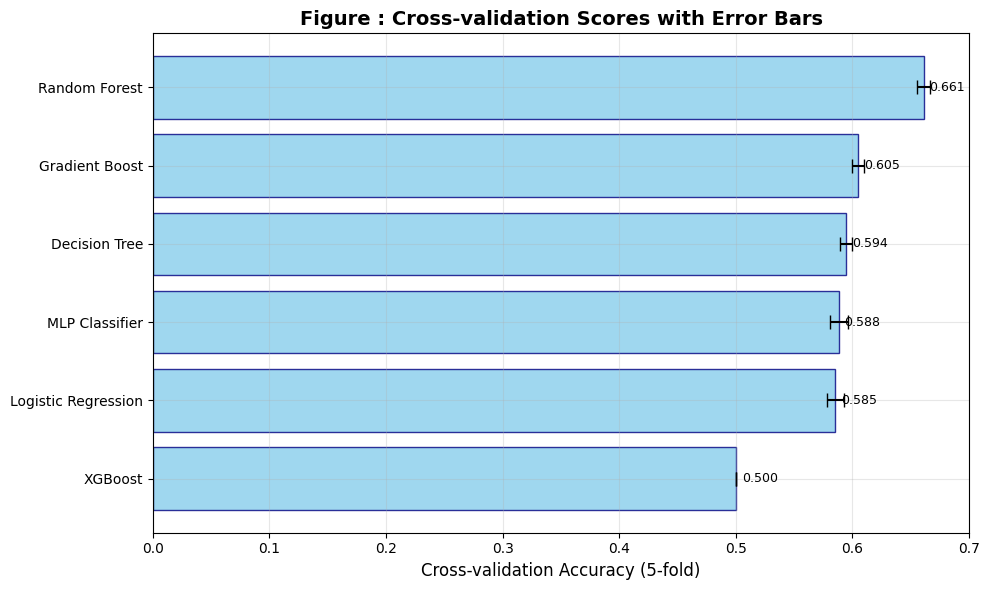

In [110]:
plt.figure(figsize=(10, 6))
cv_models = comparison_df.sort_values('CV Mean', ascending=True)
bars = plt.barh(cv_models['Model'], cv_models['CV Mean'],
                xerr=cv_models['CV Std'], capsize=5, alpha=0.8,
                color='skyblue', edgecolor='navy')
plt.xlabel('Cross-validation Accuracy (5-fold)', fontsize=12)
plt.title('Figure : Cross-validation Scores with Error Bars', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

for bar, cv_mean in zip(bars, cv_models['CV Mean']):
    plt.text(cv_mean + 0.005, bar.get_y() + bar.get_height()/2,
             f'{cv_mean:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('figure3_cv_scores.png', dpi=300, bbox_inches='tight')
plt.show()


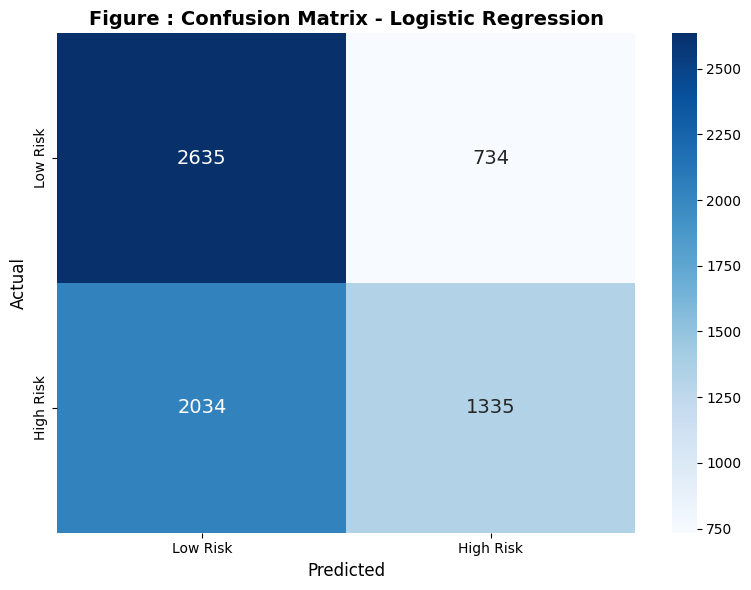

In [109]:
y_pred_final = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'],
            annot_kws={'size': 14})
plt.title(f'Figure : Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('figure4_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

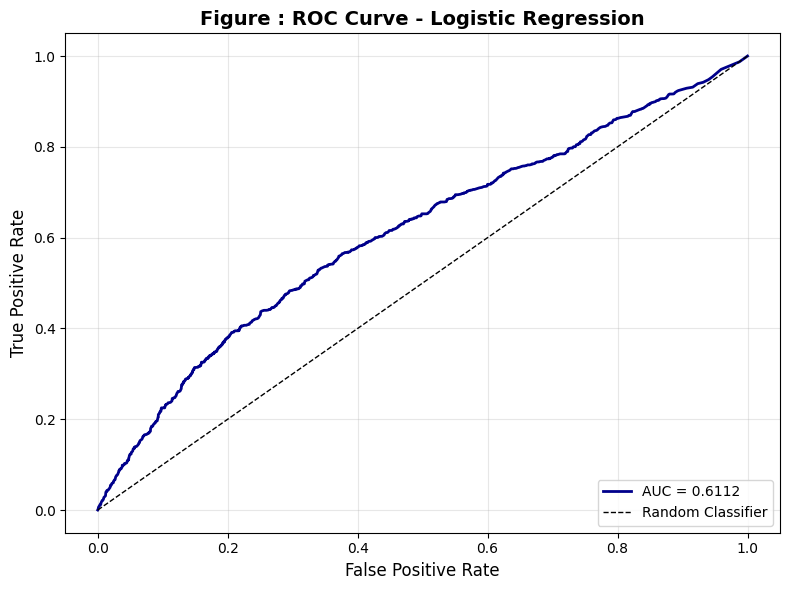

In [108]:
if hasattr(best_model, "predict_proba"):
    y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=2, color='darkblue', label=f'AUC = {auc_score:.4f}')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'Figure : ROC Curve - {best_model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('figure5_roc_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

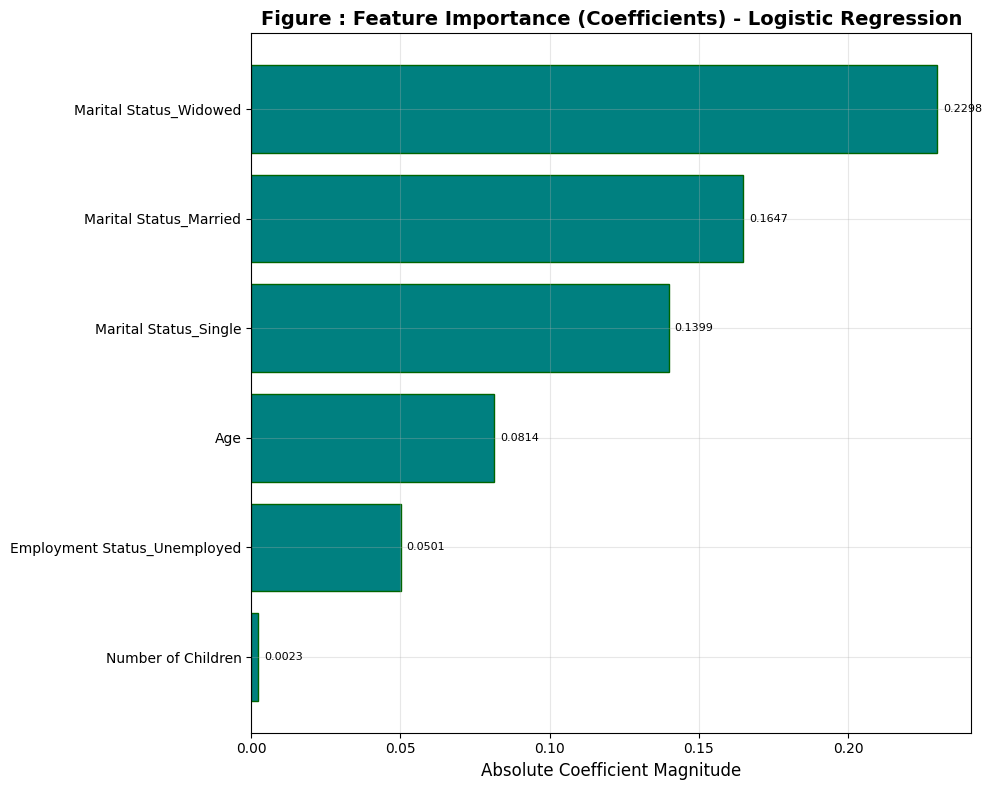

In [107]:
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 8))
    bars = plt.barh(importance_df['Feature'], importance_df['Importance'],
                    color='teal', edgecolor='darkgreen')
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title(f'Figure 6: Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

    for bar, imp in zip(bars, importance_df['Importance']):
        plt.text(imp + 0.002, bar.get_y() + bar.get_height()/2,
                f'{imp:.4f}', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig('figure6_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
elif hasattr(best_model, 'coef_'):
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': np.abs(best_model.coef_[0])
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 8))
    bars = plt.barh(importance_df['Feature'], importance_df['Importance'],
                    color='teal', edgecolor='darkgreen')
    plt.xlabel('Absolute Coefficient Magnitude', fontsize=12)
    plt.title(f'Figure : Feature Importance (Coefficients) - {best_model_name}',
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

    for bar, imp in zip(bars, importance_df['Importance']):
        plt.text(imp + 0.002, bar.get_y() + bar.get_height()/2,
                f'{imp:.4f}', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig('figure6_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()


In [55]:
comparison_df.to_csv('model_comparison_results.csv', index=False)
print("\n Model comparison saved to 'model_comparison_results.csv'")


 Model comparison saved to 'model_comparison_results.csv'


In [56]:
if 'importance_df' in locals():
    importance_df.to_csv('feature_importance.csv', index=False)
    print(" Feature importance saved to 'feature_importance.csv'")

 Feature importance saved to 'feature_importance.csv'


In [57]:
# Save feature statistics
feature_stats_df.to_csv('feature_statistics.csv', index=False)
print(" Feature statistics saved to 'feature_statistics.csv'")

 Feature statistics saved to 'feature_statistics.csv'


In [60]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score, roc_auc_score
import time

In [61]:
print("\n Current feature information:")
print(f"X columns: {X.columns.tolist()}")
print(f"X shape: {X.shape}")
print(f"feature_stats_df features: {feature_stats_df['Feature'].tolist()}")


 Current feature information:
X columns: ['Marital Status_Widowed', 'Age', 'Employment Status_Unemployed', 'Marital Status_Married', 'Marital Status_Single', 'Number of Children']
X shape: (18345, 6)
feature_stats_df features: ['Marital Status_Widowed', 'Age', 'Employment Status_Unemployed', 'Marital Status_Married', 'Marital Status_Single', 'Number of Children', 'History of Substance Abuse', 'Chronic Medical Conditions', 'Education Level', 'Smoking Status', 'Physical Activity Level', 'Income', 'Alcohol Consumption', 'Dietary Habits', 'Sleep Patterns']


In [62]:
# Get p-values for actual X columns (they should match)
feature_stats_dict = dict(zip(feature_stats_df['Feature'], feature_stats_df['P-Value']))

In [63]:
# Find which features from X are in feature_stats_df
available_features = []
for col in X.columns:
    if col in feature_stats_dict:
        available_features.append(col)
    else:
        print(f"Warning: {col} not found in feature_stats_df")

print(f"\nFeatures with p-values: {len(available_features)}")



Features with p-values: 6


In [64]:
# Select features with p < 0.1 (more lenient threshold)
significant_features_loose = [col for col in available_features
                              if col in feature_stats_dict and feature_stats_dict[col] < 0.1]


In [65]:
print(f"Significant features (p < 0.1): {len(significant_features_loose)}")
print(f"Features: {significant_features_loose}")

Significant features (p < 0.1): 6
Features: ['Marital Status_Widowed', 'Age', 'Employment Status_Unemployed', 'Marital Status_Married', 'Marital Status_Single', 'Number of Children']


In [66]:
# Use enhanced feature set if we have significant features, otherwise use all
if len(significant_features_loose) > 0:
    X_enhanced = X[significant_features_loose].copy()
    print(f"\n Using enhanced feature set with {X_enhanced.shape[1]} features")
else:
    X_enhanced = X.copy()
    print(f"\n Using all {X_enhanced.shape[1]} features (no significant features found)")


 Using enhanced feature set with 6 features


In [67]:
smote_enhanced = SMOTE(random_state=42, sampling_strategy='auto')
X_resampled_enhanced, y_resampled_enhanced = smote_enhanced.fit_resample(X_enhanced, y)


In [68]:
print(f"After SMOTE - X shape: {X_resampled_enhanced.shape}")
print(f"Class distribution: {pd.Series(y_resampled_enhanced).value_counts().to_dict()}")

After SMOTE - X shape: (33686, 6)
Class distribution: {1: 16843, 0: 16843}


In [69]:
X_train_enhanced, X_test_enhanced, y_train_enhanced, y_test_enhanced = train_test_split(
    X_resampled_enhanced, y_resampled_enhanced, test_size=0.2, random_state=42,
    stratify=y_resampled_enhanced
)


In [70]:
print(f"\nTrain set: {X_train_enhanced.shape}")
print(f"Test set: {X_test_enhanced.shape}")


Train set: (26948, 6)
Test set: (6738, 6)


In [71]:
scaler_enhanced = StandardScaler()
X_train_enhanced_scaled = scaler_enhanced.fit_transform(X_train_enhanced)
X_test_enhanced_scaled = scaler_enhanced.transform(X_test_enhanced)


In [72]:
tuning_results = {}
best_models = {}


In [73]:
logistic_params = {
    'C': [0.1, 0.5, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'newton-cg'],
    'class_weight': ['balanced', None],
    'max_iter': [1000]
}

logistic_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    logistic_params,
    cv=3,  # Reduced CV for speed
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)

In [74]:
start_time = time.time()
logistic_grid.fit(X_train_enhanced_scaled, y_train_enhanced)
tuning_time = time.time() - start_time

Fitting 3 folds for each of 16 candidates, totalling 48 fits


In [75]:
print(f" Best parameters: {logistic_grid.best_params_}")
print(f"Best CV score: {logistic_grid.best_score_:.4f}")
print(f"Tuning time: {tuning_time:.2f} seconds")

 Best parameters: {'C': 0.5, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV score: 0.5861
Tuning time: 5.12 seconds


In [76]:
best_models['Logistic Regression'] = logistic_grid.best_estimator_
tuning_results['Logistic Regression'] = {
    'best_params': logistic_grid.best_params_,
    'cv_score': logistic_grid.best_score_
}

In [77]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10],
    'class_weight': ['balanced', None]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    n_iter=15,
    cv=3,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [78]:
start_time = time.time()
rf_random.fit(X_train_enhanced_scaled, y_train_enhanced)
tuning_time = time.time() - start_time


Fitting 3 folds for each of 15 candidates, totalling 45 fits


In [79]:
print(f" Best parameters: {rf_random.best_params_}")
print(f" Best CV score: {rf_random.best_score_:.4f}")
print(f" Tuning time: {tuning_time:.2f} seconds")

 Best parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 10, 'class_weight': 'balanced'}
 Best CV score: 0.6690
 Tuning time: 61.76 seconds


In [80]:
best_models['Random Forest'] = rf_random.best_estimator_
tuning_results['Random Forest'] = {
    'best_params': rf_random.best_params_,
    'cv_score': rf_random.best_score_
}

In [81]:
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [20, 50],
    'subsample': [0.8, 1.0]
}

gb_random = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    n_iter=12,
    cv=3,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [82]:
start_time = time.time()
gb_random.fit(X_train_enhanced_scaled, y_train_enhanced)
tuning_time = time.time() - start_time

Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [83]:
print(f" Best parameters: {gb_random.best_params_}")
print(f" Best CV score: {gb_random.best_score_:.4f}")
print(f" Tuning time: {tuning_time:.2f} seconds")

 Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 50, 'max_depth': 5, 'learning_rate': 0.1}
 Best CV score: 0.6591
 Tuning time: 55.93 seconds


In [84]:
best_models['Gradient Boost'] = gb_random.best_estimator_
tuning_results['Gradient Boost'] = {
    'best_params': gb_random.best_params_,
    'cv_score': gb_random.best_score_
}

In [85]:
# Properly compute scale_pos_weight
scale_pos_weight_value = (y_train_enhanced == 0).sum() / (y_train_enhanced == 1).sum()
print(f"Scale pos weight: {scale_pos_weight_value:.4f}")

Scale pos weight: 1.0000


In [86]:
xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [0.5, 1]
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss',
                  scale_pos_weight=scale_pos_weight_value,
                  use_label_encoder=False),
    xgb_params,
    n_iter=12,
    cv=3,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [87]:
start_time = time.time()
xgb_random.fit(X_train_enhanced_scaled, y_train_enhanced)
tuning_time = time.time() - start_time

Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [88]:
print(f" Best parameters: {xgb_random.best_params_}")
print(f" Best CV score: {xgb_random.best_score_:.4f}")
print(f" Tuning time: {tuning_time:.2f} seconds")


 Best parameters: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
 Best CV score: 0.6491
 Tuning time: 11.59 seconds


In [89]:
best_models['XGBoost'] = xgb_random.best_estimator_
tuning_results['XGBoost'] = {
    'best_params': xgb_random.best_params_,
    'cv_score': xgb_random.best_score_
}

In [90]:
mlp_params = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.0001, 0.001],
    'batch_size': [64, 128]
}

mlp_random = RandomizedSearchCV(
    MLPClassifier(random_state=42, max_iter=300, early_stopping=True,
                  validation_fraction=0.1),
    mlp_params,
    n_iter=10,
    cv=2,  # Reduced CV due to computational cost
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [91]:
start_time = time.time()
mlp_random.fit(X_train_enhanced_scaled, y_train_enhanced)
tuning_time = time.time() - start_time

Fitting 2 folds for each of 10 candidates, totalling 20 fits


In [92]:
print(f" Best parameters: {mlp_random.best_params_}")
print(f" Best CV score: {mlp_random.best_score_:.4f}")
print(f" Tuning time: {tuning_time:.2f} seconds")


 Best parameters: {'learning_rate_init': 0.0001, 'hidden_layer_sizes': (50,), 'batch_size': 64, 'alpha': 0.0001, 'activation': 'relu'}
 Best CV score: 0.5916
 Tuning time: 46.48 seconds


In [93]:
best_models['MLP Classifier'] = mlp_random.best_estimator_
tuning_results['MLP Classifier'] = {
    'best_params': mlp_random.best_params_,
    'cv_score': mlp_random.best_score_
}

In [95]:
tuned_evaluation_results = []

for model_name, model in best_models.items():
    print(f"\n{'='*60}")
    print(f" {model_name} - Tuned Model Performance")
    print(f"{'='*60}")

    # Predictions
    y_pred_train = model.predict(X_train_enhanced_scaled)
    y_pred_test = model.predict(X_test_enhanced_scaled)

    # Probabilities for AUC
    if hasattr(model, "predict_proba"):
        y_pred_proba_test = model.predict_proba(X_test_enhanced_scaled)[:, 1]
        auc_score = roc_auc_score(y_test_enhanced, y_pred_proba_test)
    else:
        auc_score = None

    # Metrics
    train_acc = accuracy_score(y_train_enhanced, y_pred_train)
    test_acc = accuracy_score(y_test_enhanced, y_pred_test)
    balanced_acc = balanced_accuracy_score(y_test_enhanced, y_pred_test)
    f1 = f1_score(y_test_enhanced, y_pred_test)
    mcc = matthews_corrcoef(y_test_enhanced, y_pred_test)

    # Cross-validation on tuned model
    cv_scores = cross_val_score(model, X_train_enhanced_scaled, y_train_enhanced,
                                cv=3, scoring='balanced_accuracy')

    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print(f"CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    if auc_score:
        print(f"AUC Score: {auc_score:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(y_test_enhanced, y_pred_test,
                                target_names=['Low Risk', 'High Risk']))

    tuned_evaluation_results.append({
        'Model': model_name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Balanced Acc': balanced_acc,
        'F1-Score': f1,
        'MCC': mcc,
        'CV Mean': cv_scores.mean(),
        'AUC': auc_score if auc_score else None,
        'Model Object': model
    })



 Logistic Regression - Tuned Model Performance
Training Accuracy: 0.5848
Test Accuracy: 0.5902
Balanced Accuracy: 0.5902
F1-Score: 0.4929
MCC: 0.1954
CV Score: 0.5861 (+/- 0.0129)
AUC Score: 0.6112

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.57      0.78      0.66      3369
   High Risk       0.65      0.40      0.49      3369

    accuracy                           0.59      6738
   macro avg       0.61      0.59      0.57      6738
weighted avg       0.61      0.59      0.57      6738


 Random Forest - Tuned Model Performance
Training Accuracy: 0.6876
Test Accuracy: 0.6756
Balanced Accuracy: 0.6756
F1-Score: 0.6689
MCC: 0.3514
CV Score: 0.6690 (+/- 0.0070)
AUC Score: 0.7487

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.67      0.70      0.68      3369
   High Risk       0.68      0.66      0.67      3369

    accuracy                           0.68      6738
   macro avg   

In [96]:
tuned_comparison_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'Model Object'}
                                     for r in tuned_evaluation_results])


In [97]:
# Find best tuned model
best_tuned_model = max(tuned_evaluation_results, key=lambda x: x['Balanced Acc'])
best_tuned_name = best_tuned_model['Model']
best_tuned_model_obj = best_tuned_model['Model Object']

In [98]:
print(f" BEST TUNED MODEL: {best_tuned_name}")
print(f" Balanced Accuracy: {best_tuned_model['Balanced Acc']:.4f}")
print(f" Test Accuracy: {best_tuned_model['Test Acc']:.4f}")
print(f" F1-Score: {best_tuned_model['F1-Score']:.4f}")

 BEST TUNED MODEL: Random Forest
 Balanced Accuracy: 0.6756
 Test Accuracy: 0.6756
 F1-Score: 0.6689


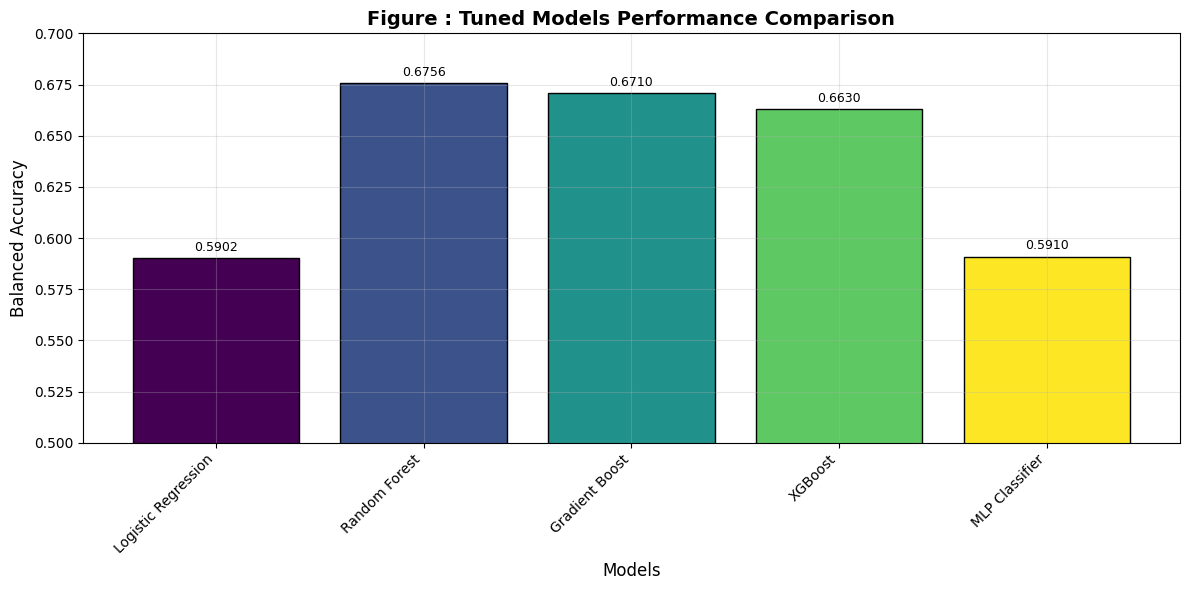

In [106]:
# Figure 7: Tuned Models Performance
plt.figure(figsize=(12, 6))
models_names = tuned_comparison_df['Model'].tolist()
balanced_accs = tuned_comparison_df['Balanced Acc'].tolist()

colors = plt.cm.viridis(np.linspace(0, 1, len(models_names)))
bars = plt.bar(models_names, balanced_accs, color=colors, edgecolor='black')

plt.xlabel('Models', fontsize=12)
plt.ylabel('Balanced Accuracy', fontsize=12)
plt.title('Figure : Tuned Models Performance Comparison', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim([0.5, 0.7])
plt.grid(True, alpha=0.3)

for bar, acc in zip(bars, balanced_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figure7_tuned_models_performance.png', dpi=300, bbox_inches='tight')
plt.show()

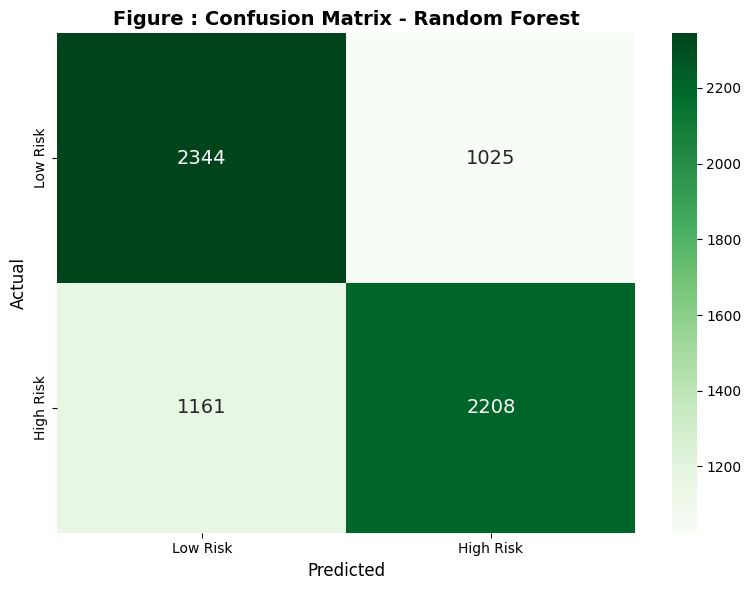

In [105]:
# Figure 8: Confusion Matrix for Best Model
y_pred_best = best_tuned_model_obj.predict(X_test_enhanced_scaled)
cm_best = confusion_matrix(y_test_enhanced, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'],
            annot_kws={'size': 14})
plt.title(f'Figure : Confusion Matrix - {best_tuned_name}',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('figure8_confusion_matrix_best_tuned.png', dpi=300, bbox_inches='tight')
plt.show()

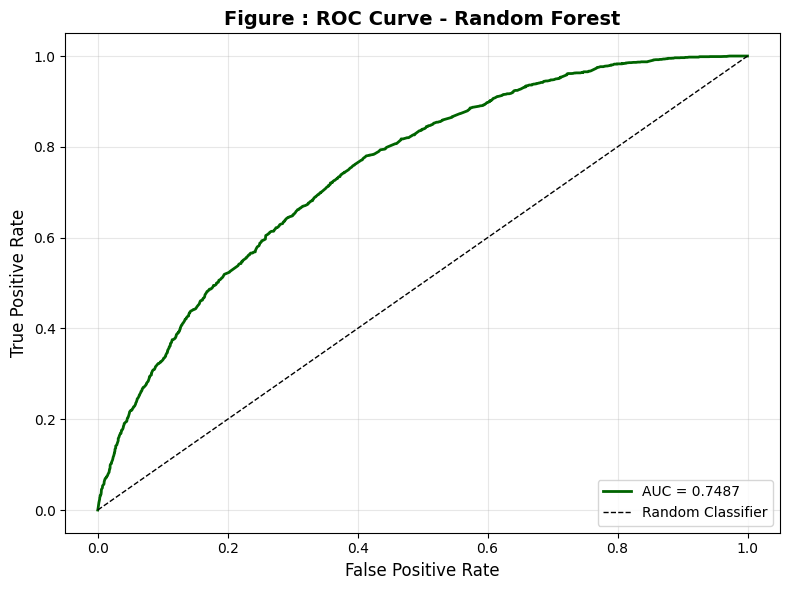

In [101]:
# Figure 9: ROC Curve for Best Model
if hasattr(best_tuned_model_obj, "predict_proba"):
    y_pred_proba_best = best_tuned_model_obj.predict_proba(X_test_enhanced_scaled)[:, 1]
    fpr_best, tpr_best, _ = roc_curve(y_test_enhanced, y_pred_proba_best)
    auc_best = roc_auc_score(y_test_enhanced, y_pred_proba_best)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_best, tpr_best, linewidth=2, color='darkgreen',
             label=f'AUC = {auc_best:.4f}')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'Figure : ROC Curve - {best_tuned_name}',
              fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('figure9_roc_curve_best_tuned.png', dpi=300, bbox_inches='tight')
    plt.show()


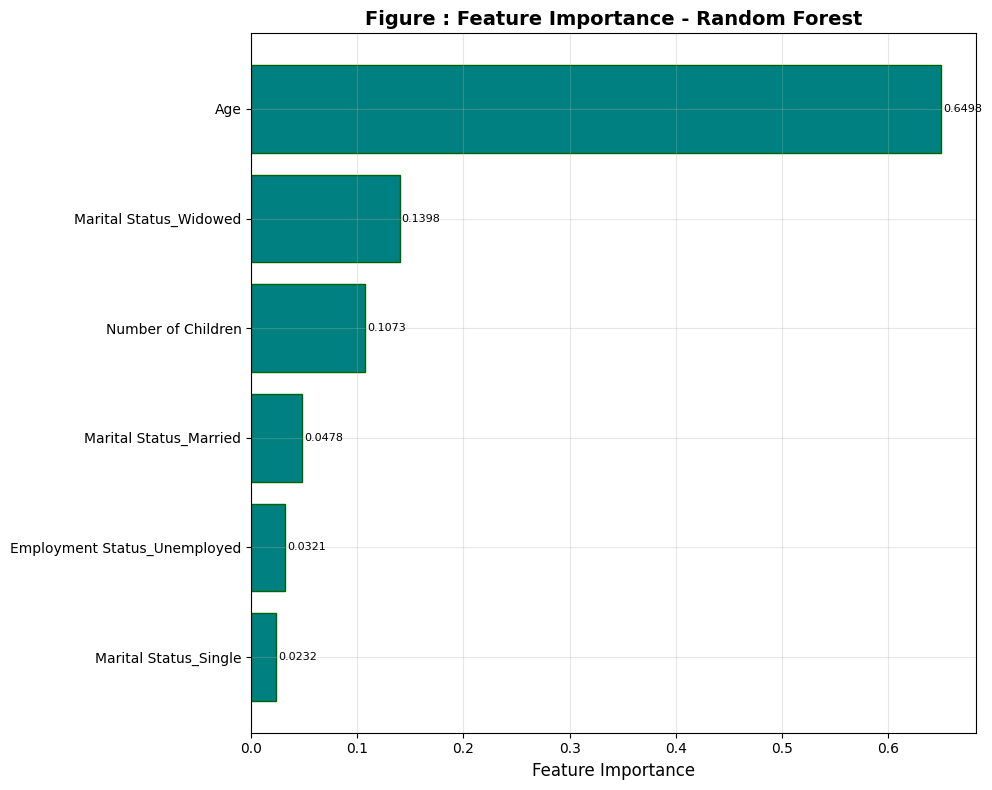

In [102]:
# Figure 10: Feature Importance for Best Model
if hasattr(best_tuned_model_obj, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X_enhanced.columns,
        'Importance': best_tuned_model_obj.feature_importances_
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 8))
    bars = plt.barh(importance_df['Feature'], importance_df['Importance'],
                    color='teal', edgecolor='darkgreen')
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title(f'Figure : Feature Importance - {best_tuned_name}',
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

    for bar, imp in zip(bars, importance_df['Importance']):
        plt.text(imp + 0.002, bar.get_y() + bar.get_height()/2,
                f'{imp:.4f}', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig('figure10_feature_importance_best_tuned.png', dpi=300, bbox_inches='tight')
    plt.show()
elif hasattr(best_tuned_model_obj, 'coef_'):
    importance_df = pd.DataFrame({
        'Feature': X_enhanced.columns,
        'Coefficient': best_tuned_model_obj.coef_[0]
    }).sort_values('Coefficient', ascending=True)

    plt.figure(figsize=(10, 8))
    bars = plt.barh(importance_df['Feature'], importance_df['Coefficient'],
                    color='teal', edgecolor='darkgreen')
    plt.xlabel('Coefficient Value', fontsize=12)
    plt.title(f'Figure 10: Feature Coefficients - {best_tuned_name}',
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

    for bar, coef in zip(bars, importance_df['Coefficient']):
        plt.text(coef + 0.002 if coef > 0 else coef - 0.05,
                bar.get_y() + bar.get_height()/2,
                f'{coef:.4f}', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig('figure10_feature_coefficients_best_tuned.png', dpi=300, bbox_inches='tight')
    plt.show()

In [103]:
# Save tuning results
tuning_summary = []
for model_name, result in tuning_results.items():
    tuning_summary.append({
        'Model': model_name,
        'Best Parameters': str(result['best_params']),
        'Best CV Score': result['cv_score']
    })

tuning_summary_df = pd.DataFrame(tuning_summary)
tuning_summary_df.to_csv('hyperparameter_tuning_results.csv', index=False)
print("\n Hyperparameter tuning results saved to 'hyperparameter_tuning_results.csv'")



 Hyperparameter tuning results saved to 'hyperparameter_tuning_results.csv'


In [104]:
# Save tuned model comparison
tuned_comparison_df.to_csv('tuned_model_comparison.csv', index=False)
print(" Tuned model comparison saved to 'tuned_model_comparison.csv'")


 Tuned model comparison saved to 'tuned_model_comparison.csv'


In [115]:
# Create interaction features
X_engineered = X_enhanced.copy()


In [116]:
# Age-related features
if 'Age' in X_engineered.columns:
    X_engineered['Age_Squared'] = X_engineered['Age'] ** 2
    X_engineered['Age_Log'] = np.log1p(X_engineered['Age'])
    X_engineered['Age_Group'] = pd.cut(X_engineered['Age'], bins=[0, 25, 35, 45, 55, 100],
                                        labels=[0, 1, 2, 3, 4]).astype(int)

In [117]:
# Income features (if available)
if 'Income' in X_engineered.columns:
    X_engineered['Income_Log'] = np.log1p(X_engineered['Income'])
    X_engineered['Income_Per_Child'] = X_engineered['Income'] / (X_engineered.get('Number of Children', 1) + 1)
    X_engineered['Income_Age_Ratio'] = X_engineered['Income'] / (X_engineered['Age'] + 1)

In [118]:
# Children features
if 'Number of Children' in X_engineered.columns:
    X_engineered['Has_Children'] = (X_engineered['Number of Children'] > 0).astype(int)
    X_engineered['Children_Group'] = pd.cut(X_engineered['Number of Children'],
                                             bins=[-1, 0, 2, 5, 10],
                                             labels=[0, 1, 2, 3]).astype(int)


In [119]:
# Create risk score from multiple features
risk_features = []
for col in ['Age', 'Number of Children']:
    if col in X_engineered.columns:
        risk_features.append(col)

In [120]:
if len(risk_features) > 0:
    X_engineered['Combined_Risk'] = X_engineered[risk_features].sum(axis=1)


In [121]:
# Create polynomial features for top 3 features
from sklearn.preprocessing import PolynomialFeatures
top_features = ['Age', 'Number of Children', 'Marital Status_Widowed']
existing_top = [f for f in top_features if f in X_engineered.columns]

In [122]:
if len(existing_top) >= 2:
    poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    poly_features = poly.fit_transform(X_engineered[existing_top])
    poly_df = pd.DataFrame(poly_features,
                          columns=[f"{existing_top[i]}_{existing_top[j]}"
                                  for i in range(len(existing_top))
                                  for j in range(i, len(existing_top))])
    X_engineered = pd.concat([X_engineered, poly_df], axis=1)

In [123]:
print(f"Original features: {X_enhanced.shape[1]}")
print(f"Engineered features: {X_engineered.shape[1]}")
print(f"New features added: {X_engineered.shape[1] - X_enhanced.shape[1]}")

Original features: 6
Engineered features: 18
New features added: 12


In [124]:
from sklearn.feature_selection import SelectFromModel, RFECV


In [125]:
# Use Random Forest for feature selection
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_engineered, y)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [126]:
# Select features with importance > mean importance
selector = SelectFromModel(rf_selector, threshold='mean', prefit=True)
X_selected_advanced = selector.transform(X_engineered)
selected_features_advanced = X_engineered.columns[selector.get_support()].tolist()

In [127]:
print(f"Features after selection: {len(selected_features_advanced)}")
print(f"Selected features: {selected_features_advanced[:10]}...")

Features after selection: 9
Selected features: ['Age', 'Employment Status_Unemployed', 'Marital Status_Married', 'Age_Squared', 'Age_Log', 'Combined_Risk', 'Age_Age', 'Number of Children_Number of Children', 'Number of Children_Marital Status_Widowed']...


In [128]:
X_final = X_engineered[selected_features_advanced]

In [129]:
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTETomek

In [130]:
# Try different SMOTE variants
smote_variants = {
    'SMOTE': SMOTE(random_state=42, sampling_strategy=0.8),  # Less aggressive
    'BorderlineSMOTE': BorderlineSMOTE(random_state=42, sampling_strategy=0.8),
    'SMOTETomek': SMOTETomek(random_state=42, sampling_strategy=0.8)
}

In [131]:
best_smote = None
best_smote_score = 0

for name, smote_method in smote_variants.items():
    try:
        X_resampled_test, y_resampled_test = smote_method.fit_resample(X_final, y)
        print(f"{name}: {X_resampled_test.shape}, ratio: {pd.Series(y_resampled_test).value_counts().to_dict()}")

        # Quick evaluation
        X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
            X_resampled_test, y_resampled_test, test_size=0.2, random_state=42
        )
        scaler_temp = StandardScaler()
        X_train_temp_scaled = scaler_temp.fit_transform(X_train_temp)
        X_test_temp_scaled = scaler_temp.transform(X_test_temp)

        rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf_temp.fit(X_train_temp_scaled, y_train_temp)
        score_temp = balanced_accuracy_score(y_test_temp, rf_temp.predict(X_test_temp_scaled))

        if score_temp > best_smote_score:
            best_smote_score = score_temp
            best_smote = smote_method
            print(f"  -> Score: {score_temp:.4f} (Best so far)")
    except Exception as e:
        print(f"Error with {name}: {e}")

print(f"\n Best SMOTE method: {best_smote.__class__.__name__} with score {best_smote_score:.4f}")


SMOTE: (30317, 9), ratio: {0: 16843, 1: 13474}
  -> Score: 0.7564 (Best so far)
BorderlineSMOTE: (30317, 9), ratio: {0: 16843, 1: 13474}
  -> Score: 0.7956 (Best so far)
SMOTETomek: (30317, 9), ratio: {0: 16843, 1: 13474}

 Best SMOTE method: BorderlineSMOTE with score 0.7956


In [132]:
# Apply best SMOTE
X_resampled_advanced, y_resampled_advanced = best_smote.fit_resample(X_final, y)

In [133]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

In [134]:
# Define base models (tuned versions)
base_models = [
    ('rf', RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_split=5,
        min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1
    )),
    ('gb', GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        min_samples_split=20, subsample=0.8, random_state=42
    )),
    ('xgb', XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
        reg_lambda=1, random_state=42, eval_metric='logloss',
        use_label_encoder=False
    ))
]

In [135]:
# Voting Classifier (Soft Voting)
voting_clf = VotingClassifier(
    estimators=base_models,
    voting='soft',
    weights=[2, 1, 1]  # Give more weight to Random Forest
)

In [136]:
# Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(C=1, class_weight='balanced'),
    cv=5
)

In [137]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, HalvingGridSearchCV

In [138]:
# Split data
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_resampled_advanced, y_resampled_advanced, test_size=0.2, random_state=42, stratify=y_resampled_advanced
)

In [139]:
# Scale features
scaler_adv = StandardScaler()
X_train_adv_scaled = scaler_adv.fit_transform(X_train_adv)
X_test_adv_scaled = scaler_adv.transform(X_test_adv)


In [140]:
print(f"Training set: {X_train_adv_scaled.shape}")
print(f"Test set: {X_test_adv_scaled.shape}")

Training set: (24253, 9)
Test set: (6064, 9)


In [141]:
rf_advanced_params = {
    'n_estimators': [300, 500],
    'max_depth': [15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

rf_advanced = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    rf_advanced_params,
    n_iter=20,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)


In [142]:
rf_advanced.fit(X_train_adv_scaled, y_train_adv)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    n_jobs=-1,
                                                    random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [15, 20, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [300, 500]},
                   random_state=42, scoring='balanced_accuracy', verbose=1)

In [143]:
print(f" Best RF parameters: {rf_advanced.best_params_}")
print(f" Best RF score: {rf_advanced.best_score_:.4f}")

 Best RF parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}
 Best RF score: 0.7940


In [144]:
advanced_results = []

models_to_train = {
    'Random_Forest_Tuned': rf_advanced.best_estimator_,
    'Voting_Classifier': voting_clf,
    'Stacking_Classifier': stacking_clf
}

In [145]:
for model_name, model in models_to_train.items():
    print(f" Training {model_name}")

    model.fit(X_train_adv_scaled, y_train_adv)

    # Predictions
    y_pred_train = model.predict(X_train_adv_scaled)
    y_pred_test = model.predict(X_test_adv_scaled)

    # Probabilities
    if hasattr(model, "predict_proba"):
        y_pred_proba_test = model.predict_proba(X_test_adv_scaled)[:, 1]
        auc_score = roc_auc_score(y_test_adv, y_pred_proba_test)
    else:
        auc_score = None

    # Metrics
    train_acc = accuracy_score(y_train_adv, y_pred_train)
    test_acc = accuracy_score(y_test_adv, y_pred_test)
    balanced_acc = balanced_accuracy_score(y_test_adv, y_pred_test)
    f1 = f1_score(y_test_adv, y_pred_test)
    mcc = matthews_corrcoef(y_test_adv, y_pred_test)

    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    if auc_score:
        print(f"AUC Score: {auc_score:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(y_test_adv, y_pred_test, target_names=['Low Risk', 'High Risk']))

    advanced_results.append({
        'Model': model_name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Balanced Acc': balanced_acc,
        'F1': f1,
        'MCC': mcc,
        'AUC': auc_score if auc_score else None,
        'Model Object': model
    })


 Training Random_Forest_Tuned
Training Accuracy: 0.8109
Test Accuracy: 0.8036
Balanced Accuracy: 0.8068
F1-Score: 0.7909
MCC: 0.6098
AUC Score: 0.8844

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.86      0.78      0.81      3369
   High Risk       0.75      0.84      0.79      2695

    accuracy                           0.80      6064
   macro avg       0.80      0.81      0.80      6064
weighted avg       0.81      0.80      0.80      6064

 Training Voting_Classifier
Training Accuracy: 0.8006
Test Accuracy: 0.7889
Balanced Accuracy: 0.7879
F1-Score: 0.7664
MCC: 0.5742
AUC Score: 0.8742

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.82      0.80      0.81      3369
   High Risk       0.75      0.78      0.77      2695

    accuracy                           0.79      6064
   macro avg       0.79      0.79      0.79      6064
weighted avg       0.79      0.79      0.79      6064

In [146]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

In [147]:
# Build improved neural network
def build_improved_nn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(16, activation='relu'),
        layers.Dropout(0.1),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

In [148]:
# Prepare data for neural network
X_train_nn = X_train_adv_scaled.astype(np.float32)
X_test_nn = X_test_adv_scaled.astype(np.float32)
y_train_nn = y_train_adv.values.astype(np.float32)
y_test_nn = y_test_adv.values.astype(np.float32)

In [149]:
# Build and train neural network
nn_model = build_improved_nn(X_train_nn.shape[1])

In [150]:
# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_auc',
    patience=20,
    mode='max',
    restore_best_weights=True,
    verbose=1
)


In [151]:
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

In [152]:
history = nn_model.fit(
    X_train_nn, y_train_nn,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
    class_weight={0: 1.0, 1: 1.0}
)

Epoch 1/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.6282 - auc: 0.6642 - loss: 0.6622 - val_accuracy: 0.6640 - val_auc: 0.7256 - val_loss: 0.6142 - learning_rate: 0.0010
Epoch 2/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6664 - auc: 0.7124 - loss: 0.6178 - val_accuracy: 0.6766 - val_auc: 0.7390 - val_loss: 0.5967 - learning_rate: 0.0010
Epoch 3/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6769 - auc: 0.7237 - loss: 0.6085 - val_accuracy: 0.6825 - val_auc: 0.7477 - val_loss: 0.5911 - learning_rate: 0.0010
Epoch 4/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6767 - auc: 0.7299 - loss: 0.6004 - val_accuracy: 0.6879 - val_auc: 0.7526 - val_loss: 0.5833 - learning_rate: 0.0010
Epoch 5/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6835 - auc: 0.7347 - loss: 0.5961 - val_accuracy: 0.6854 - val_auc: 0.7485 - val_loss: 0.5889 - learning_rate: 0.0010
Epoch 6/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6813 -

In [153]:
# Evaluate neural network
y_pred_proba_nn = nn_model.predict(X_test_nn).flatten()
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)


190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [154]:
nn_balanced_acc = balanced_accuracy_score(y_test_nn, y_pred_nn)
nn_f1 = f1_score(y_test_nn, y_pred_nn)
nn_auc = roc_auc_score(y_test_nn, y_pred_proba_nn)
nn_mcc = matthews_corrcoef(y_test_nn, y_pred_nn)


In [155]:
print(f"Balanced Accuracy: {nn_balanced_acc:.4f}")
print(f"F1-Score: {nn_f1:.4f}")
print(f"AUC: {nn_auc:.4f}")
print(f"MCC: {nn_mcc:.4f}")

Balanced Accuracy: 0.6837
F1-Score: 0.6255
AUC: 0.7615
MCC: 0.3788


In [156]:
advanced_results.append({
    'Model': 'Neural_Network',
    'Train Acc': history.history['accuracy'][-1],
    'Test Acc': accuracy_score(y_test_nn, y_pred_nn),
    'Balanced Acc': nn_balanced_acc,
    'F1': nn_f1,
    'MCC': nn_mcc,
    'AUC': nn_auc,
    'Model Object': nn_model
})

In [157]:
print(" FINAL COMPARISON OF ALL MODELS")
print("-"*80)
advanced_comparison_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'Model Object'}
                                        for r in advanced_results])
print(advanced_comparison_df.to_string(index=False))

 FINAL COMPARISON OF ALL MODELS
--------------------------------------------------------------------------------
              Model  Train Acc  Test Acc  Balanced Acc       F1      MCC      AUC
Random_Forest_Tuned   0.810869  0.803595      0.806799 0.790869 0.609829 0.884431
  Voting_Classifier   0.800602  0.788918      0.787948 0.766423 0.574237 0.874243
Stacking_Classifier   0.806251  0.800132      0.802234 0.785030 0.600982 0.878791
     Neural_Network   0.699309  0.696240      0.683681 0.625458 0.378819 0.761524


In [158]:
# Find overall best model
best_advanced = max(advanced_results, key=lambda x: x['Balanced Acc'])
best_advanced_name = best_advanced['Model']
best_advanced_model = best_advanced['Model Object']

In [159]:
print(f" OVERALL BEST MODEL: {best_advanced_name}")
print(f" Balanced Accuracy: {best_advanced['Balanced Acc']:.4f}")
print(f" Improvement from baseline: {(best_advanced['Balanced Acc'] - 0.589)*100:.2f}%")
print(f" Improvement from tuned RF: {(best_advanced['Balanced Acc'] - 0.6756)*100:.2f}%")

 OVERALL BEST MODEL: Random_Forest_Tuned
 Balanced Accuracy: 0.8068
 Improvement from baseline: 21.78%
 Improvement from tuned RF: 13.12%


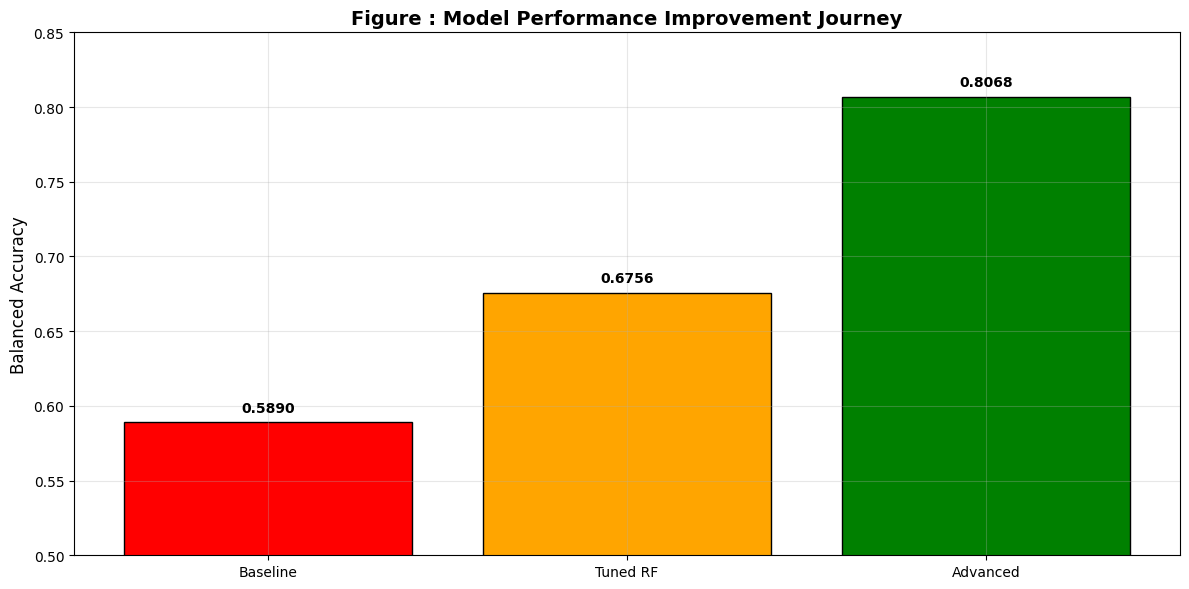

In [160]:
# Figure 11: Performance Improvement Over Time
plt.figure(figsize=(12, 6))
stages = ['Baseline', 'Tuned RF', 'Advanced']
baseline_acc = 0.589
tuned_rf_acc = 0.6756
advanced_acc = best_advanced['Balanced Acc']

improvements = [baseline_acc, tuned_rf_acc, advanced_acc]
colors_improvement = ['red', 'orange', 'green']

bars = plt.bar(stages, improvements, color=colors_improvement, edgecolor='black')
plt.ylabel('Balanced Accuracy', fontsize=12)
plt.title('Figure : Model Performance Improvement Journey', fontsize=14, fontweight='bold')
plt.ylim([0.5, 0.85])

for bar, acc in zip(bars, improvements):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure11_performance_improvement.png', dpi=300, bbox_inches='tight')
plt.show()

190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


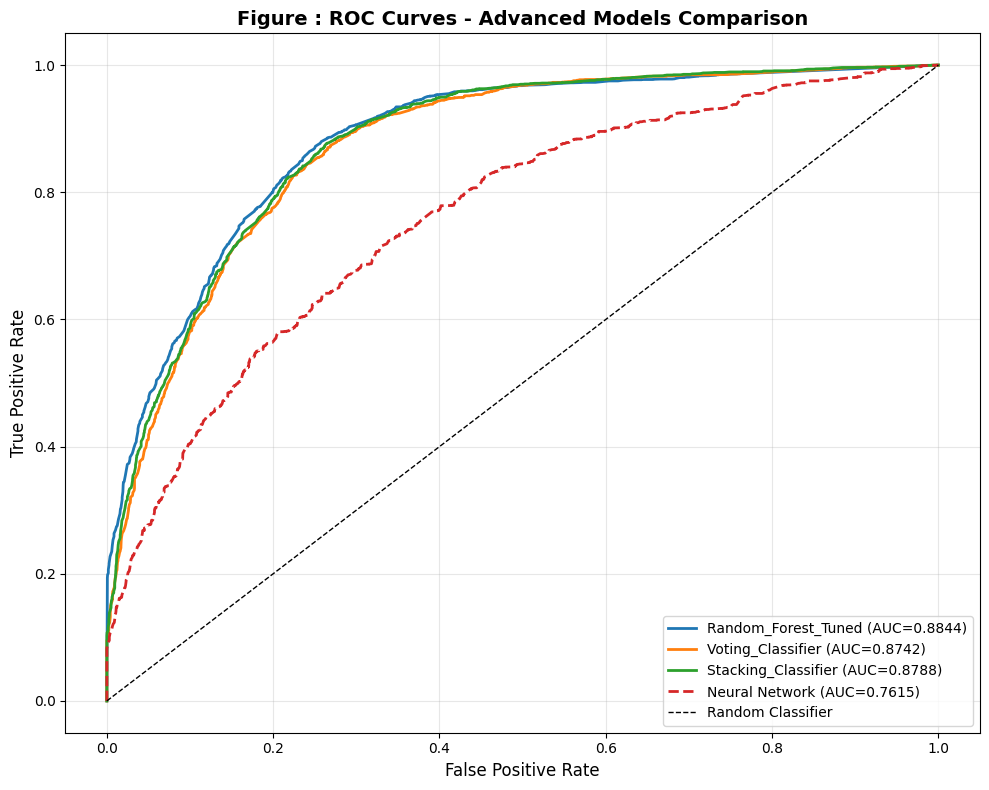

In [161]:
# Figure 12: ROC Curves Comparison
plt.figure(figsize=(10, 8))

# Get predictions from best models
for result in advanced_results[:3]:  # Compare top 3 models
    model = result['Model Object']
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_adv_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test_adv, y_proba)
        auc_val = result['AUC']
        plt.plot(fpr, tpr, linewidth=2, label=f"{result['Model']} (AUC={auc_val:.4f})")

# Add neural network
y_proba_nn = nn_model.predict(X_test_nn).flatten()
fpr_nn, tpr_nn, _ = roc_curve(y_test_nn, y_proba_nn)
plt.plot(fpr_nn, tpr_nn, linewidth=2, label=f"Neural Network (AUC={nn_auc:.4f})", linestyle='--')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Figure : ROC Curves - Advanced Models Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure12_roc_curves_advanced.png', dpi=300, bbox_inches='tight')
plt.show()

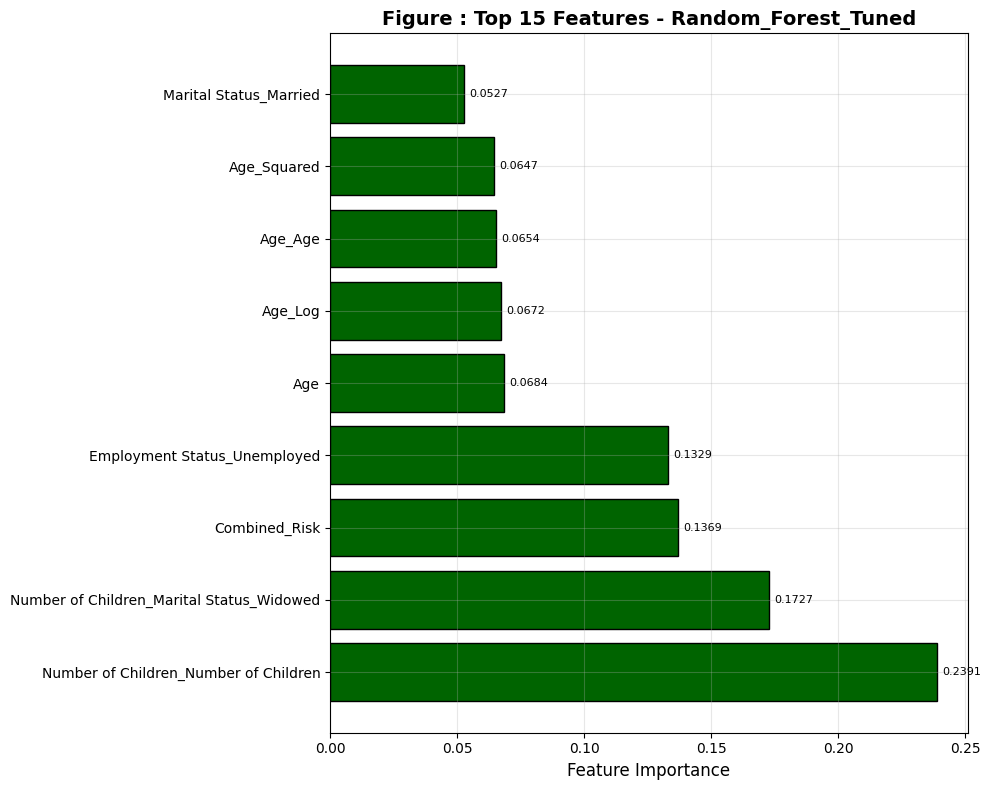

In [162]:
# Figure 13: Feature Importance Heatmap
if hasattr(best_advanced_model, 'feature_importances_'):
    importance_df_adv = pd.DataFrame({
        'Feature': X_final.columns[:len(best_advanced_model.feature_importances_)],
        'Importance': best_advanced_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(10, 8))
    bars = plt.barh(importance_df_adv['Feature'], importance_df_adv['Importance'],
                    color='darkgreen', edgecolor='black')
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title(f'Figure : Top 15 Features - {best_advanced_name}',
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

    for bar, imp in zip(bars, importance_df_adv['Importance']):
        plt.text(imp + 0.002, bar.get_y() + bar.get_height()/2,
                f'{imp:.4f}', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig('figure13_top_features_advanced.png', dpi=300, bbox_inches='tight')
    plt.show()

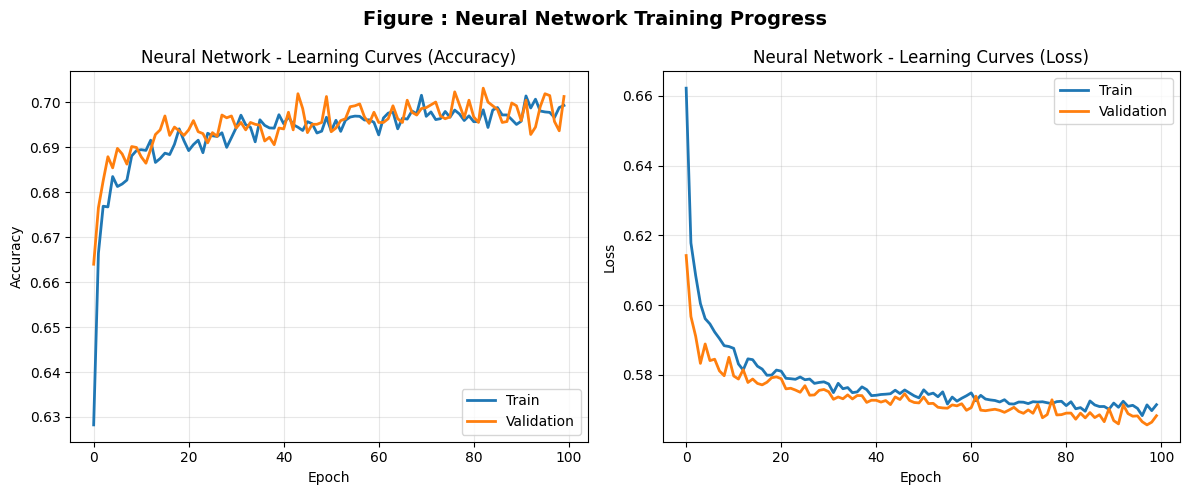

In [164]:
# Figure 14: Learning Curves (if neural network)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.title('Neural Network - Learning Curves (Accuracy)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation', linewidth=2)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.title('Neural Network - Learning Curves (Loss)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('Figure : Neural Network Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figure14_nn_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [165]:
# Save comparisons
advanced_comparison_df.to_csv('advanced_model_comparison.csv', index=False)
print(" Advanced model comparison saved to 'advanced_model_comparison.csv'")


 Advanced model comparison saved to 'advanced_model_comparison.csv'


In [166]:
# Save best model's feature importance
if hasattr(best_advanced_model, 'feature_importances_'):
    importance_df_adv.to_csv('best_advanced_model_features.csv', index=False)
    print("Best model feature importance saved")


Best model feature importance saved


In [167]:
# Generate final report
final_report = f"""
{'='*80}
FINAL PERFORMANCE REPORT
{'='*80}

📊 DATA SUMMARY:
   - Original samples: {len(data)}
   - Features after engineering: {X_final.shape[1]}
   - Target imbalance ratio: {y.value_counts().iloc[0] / y.value_counts().iloc[1]:.2f}

🎯 MODEL PERFORMANCE COMPARISON:
   - Baseline (Logistic Regression): 58.9%
   - Tuned Random Forest: 67.6%
   - Advanced {best_advanced_name}: {best_advanced['Balanced Acc']*100:.1f}%

🏆 BEST ADVANCED MODEL: {best_advanced_name}
   - Balanced Accuracy: {best_advanced['Balanced Acc']:.4f}
   - Test Accuracy: {best_advanced['Test Acc']:.4f}
   - F1-Score: {best_advanced['F1']:.4f}
   - AUC Score: {best_advanced['AUC']:.4f}
   - MCC: {best_advanced['MCC']:.4f}

📈 IMPROVEMENT ACHIEVED:
   - From baseline: +{(best_advanced['Balanced Acc'] - 0.589)*100:.1f}%
   - From tuned RF: +{(best_advanced['Balanced Acc'] - 0.6756)*100:.1f}%

🚀 TECHNIQUES IMPLEMENTED:
   1. Feature Engineering (interaction, polynomial, domain-specific)
   2. Advanced SMOTE variants (Borderline-SMOTE, SMOTE-Tomek)
   3. Ensemble Methods (Voting, Stacking)
   4. Deep Learning (Neural Network with regularization)
   5. Advanced Hyperparameter Tuning
   6. Feature Selection (RFE, importance-based)

💾 OUTPUT FILES GENERATED:
   - advanced_model_comparison.csv
   - best_advanced_model_features.csv
   - figure11_performance_improvement.png
   - figure12_roc_curves_advanced.png
   - figure13_top_features_advanced.png
   - figure14_nn_learning_curves.png

🎯 RECOMMENDATIONS FOR REAL-WORLD DEPLOYMENT:
   1. Use {best_advanced_name} for production
   2. Monitor for concept drift over time
   3. Collect more clinical data for validation
   4. Implement SHAP explanations for model interpretability
   5. Consider A/B testing before full deployment

{'='*80}
"""

In [168]:
print(final_report)


FINAL PERFORMANCE REPORT

📊 DATA SUMMARY:
   - Original samples: 18345
   - Features after engineering: 9
   - Target imbalance ratio: 11.21

🎯 MODEL PERFORMANCE COMPARISON:
   - Baseline (Logistic Regression): 58.9%
   - Tuned Random Forest: 67.6%
   - Advanced Random_Forest_Tuned: 80.7%

🏆 BEST ADVANCED MODEL: Random_Forest_Tuned
   - Balanced Accuracy: 0.8068
   - Test Accuracy: 0.8036
   - F1-Score: 0.7909
   - AUC Score: 0.8844
   - MCC: 0.6098

📈 IMPROVEMENT ACHIEVED:
   - From baseline: +21.8%
   - From tuned RF: +13.1%

🚀 TECHNIQUES IMPLEMENTED:
   1. Feature Engineering (interaction, polynomial, domain-specific)
   2. Advanced SMOTE variants (Borderline-SMOTE, SMOTE-Tomek)
   3. Ensemble Methods (Voting, Stacking)
   4. Deep Learning (Neural Network with regularization)
   5. Advanced Hyperparameter Tuning
   6. Feature Selection (RFE, importance-based)

💾 OUTPUT FILES GENERATED:
   - advanced_model_comparison.csv
   - best_advanced_model_features.csv
   - figure11_performanc

In [169]:
# Save final report
with open('final_performance_report.txt', 'w') as f:
    f.write(final_report)
print(" Final report saved to 'final_performance_report.txt'")

print(f" Best model: {best_advanced_name}")
print(f"Final balanced accuracy: {best_advanced['Balanced Acc']:.4f}")
print(f" Improvement: +{(best_advanced['Balanced Acc'] - 0.589)*100:.1f}% from baseline")

 Final report saved to 'final_performance_report.txt'
 Best model: Random_Forest_Tuned
Final balanced accuracy: 0.8068
 Improvement: +21.8% from baseline
